In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

full_tree_path = Path("trees_with_interpolated_crown_height.csv")
radius_path = Path("trees_within_radius.csv")
output_path = Path("final_imputed_crown_height.csv")

print("Full tree file exists:", full_tree_path.exists(), "-", full_tree_path)
print("Radius file exists:   ", radius_path.exists(), "-", radius_path)

trees_full = pd.read_csv(full_tree_path)
trees_radius = pd.read_csv(radius_path)





Full tree file exists: True - trees_with_interpolated_crown_height.csv
Radius file exists:    True - trees_within_radius.csv
Full tree dataset shape: (55677, 68)


/var/folders/6n/8_lfx6j975gckgr9j3ny8bdw0000gn/T/ipykernel_1510/3809114291.py:12: DtypeWarning: Columns (3,5,7,9,11,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  trees_full = pd.read_csv(full_tree_path)


In [66]:
# Merge the radius-filtered dataset with the full dataset, adding suffixes to distinguish columns from each dataset
trees_matched = trees_radius.merge(
    trees_full,
    on=key_col,
    how="left",
    validate="one_to_one",
    suffixes=("_radius", "_full")
)

In [67]:
print("Rows with no match in full dataset:")
display(trees_matched[trees_matched["CROWN_HEIGHT_interpolated"].isna()].head())

Rows with no match in full dataset:


,OBJECTID,SITE_NAME_radius,X_radius,Y_radius,EXTENT_EASTING_1_radius,EXTENT_NORTHING_1_radius,EXTENT_EASTING_2_radius,EXTENT_NORTHING_2_radius,LATIN_NAME_radius,COMMON_NAME_radius,...,created_date,last_edited_user,last_edited_date,DBH_clean,CROWN_HEIGHT_clean,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source,height_model_group
33,26611494,Horfield Road,358525.81,173623.92,358525.81,173623.92,358525.81,173623.92,Sorbus aucuparia Fastigiata,Rowan,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
57,26613029,Bedminster Road,358069.29,170607.55,358069.29,170607.55,358069.29,170607.55,Tilia cordata,Lime,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
97,26613294,Channons Hill,362898.67,175812.16,362898.67,175812.16,362898.67,175812.16,Fraxinus excelsior,Ash,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
103,26614424,Penn Street,359360.42,173341.29,359360.42,173341.29,359360.42,173341.29,Ginkgo biloba,Gingko,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
104,26614425,Penn Street,359369.38,173343.60,359369.38,173343.60,359369.38,173343.60,Ginkgo biloba,Gingko,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none


In [68]:
print("trees_radius shape:", trees_radius.shape)
print("trees_full shape:", trees_full.shape)
print("trees_matched shape:", trees_matched.shape)

trees_radius shape: (1397, 18)
trees_full shape: (55677, 68)
trees_matched shape: (1397, 85)


In [69]:
missing_dbh = trees_matched["DBH_clean"].isna()

print("Number of missing DBH_clean:", missing_dbh.sum())
display(trees_matched[missing_dbh].head())

Number of missing DBH_clean: 120


,OBJECTID,SITE_NAME_radius,X_radius,Y_radius,EXTENT_EASTING_1_radius,EXTENT_NORTHING_1_radius,EXTENT_EASTING_2_radius,EXTENT_NORTHING_2_radius,LATIN_NAME_radius,COMMON_NAME_radius,...,created_date,last_edited_user,last_edited_date,DBH_clean,CROWN_HEIGHT_clean,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source,height_model_group
33,26611494,Horfield Road,358525.81,173623.92,358525.81,173623.92,358525.81,173623.92,Sorbus aucuparia Fastigiata,Rowan,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
57,26613029,Bedminster Road,358069.29,170607.55,358069.29,170607.55,358069.29,170607.55,Tilia cordata,Lime,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
95,26613292,Channons Hill,362919.06,175827.37,362919.06,175827.37,362919.06,175827.37,Sambucus nigra,Elder,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,4.0,deciduous,4.0,0.0,observed,observed
96,26613293,Channons Hill,362913.55,175824.40,362913.55,175824.40,362913.55,175824.40,Fraxinus excelsior,Ash,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,6.0,deciduous,6.0,0.0,observed,observed
97,26613294,Channons Hill,362898.67,175812.16,362898.67,175812.16,362898.67,175812.16,Fraxinus excelsior,Ash,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none


In [70]:
zero_height = trees_matched["CROWN_HEIGHT_interpolated"] == 0

print("Number of zero crown heights:", zero_height.sum())
display(trees_matched[zero_height].head())

Number of zero crown heights: 0


,OBJECTID,SITE_NAME_radius,X_radius,Y_radius,EXTENT_EASTING_1_radius,EXTENT_NORTHING_1_radius,EXTENT_EASTING_2_radius,EXTENT_NORTHING_2_radius,LATIN_NAME_radius,COMMON_NAME_radius,...,created_date,last_edited_user,last_edited_date,DBH_clean,CROWN_HEIGHT_clean,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source,height_model_group


In [71]:
nan_height = trees_matched["CROWN_HEIGHT_interpolated"].isna()

print("Number of NaN crown heights:", nan_height.sum())
display(trees_matched[nan_height].head())



Number of NaN crown heights: 59


,OBJECTID,SITE_NAME_radius,X_radius,Y_radius,EXTENT_EASTING_1_radius,EXTENT_NORTHING_1_radius,EXTENT_EASTING_2_radius,EXTENT_NORTHING_2_radius,LATIN_NAME_radius,COMMON_NAME_radius,...,created_date,last_edited_user,last_edited_date,DBH_clean,CROWN_HEIGHT_clean,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source,height_model_group
33,26611494,Horfield Road,358525.81,173623.92,358525.81,173623.92,358525.81,173623.92,Sorbus aucuparia Fastigiata,Rowan,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
57,26613029,Bedminster Road,358069.29,170607.55,358069.29,170607.55,358069.29,170607.55,Tilia cordata,Lime,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
97,26613294,Channons Hill,362898.67,175812.16,362898.67,175812.16,362898.67,175812.16,Fraxinus excelsior,Ash,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
103,26614424,Penn Street,359360.42,173341.29,359360.42,173341.29,359360.42,173341.29,Ginkgo biloba,Gingko,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none
104,26614425,Penn Street,359369.38,173343.60,359369.38,173343.60,359369.38,173343.60,Ginkgo biloba,Gingko,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,deciduous,NaN,0.0,missing_no_dbh,none


In [72]:
# Analyze the distribution of missing values by species
nan_mask = trees_matched["CROWN_HEIGHT_interpolated"].isna()
nan_df = trees_matched[nan_mask]

#count NaN values by species
nan_counts = nan_df["COMMON_NAME_radius"].value_counts().rename("num_nan")

#count total values by species
total_counts = trees_matched["COMMON_NAME_radius"].value_counts().rename("total_count")

#combine into a table
species_nan_summary = pd.concat([nan_counts, total_counts], axis=1)
species_nan_summary["num_nan"] = species_nan_summary["num_nan"].fillna(0)
species_nan_summary["nan_percentage"] = (
    species_nan_summary["num_nan"] / species_nan_summary["total_count"]
) * 100

species_nan_summary = species_nan_summary.sort_values(by="num_nan", ascending=False)

display(species_nan_summary)

,num_nan,total_count,nan_percentage
COMMON_NAME_radius,,,
Walnut,18.0,19,94.736842
Gingko,10.0,17,58.823529
Pagoda Tree,5.0,5,100.000000
Magnolia,4.0,6,66.666667
Plane,1.0,235,0.425532
...,...,...,...
Acacia,0.0,9,0.000000
Willow,0.0,8,0.000000
Beech,0.0,8,0.000000


In [ ]:
# From full dataset (before radius filter)
species_means_full = trees_full.groupby("COMMON_NAME")["CROWN_HEIGHT_interpolated"].mean()

group_means_full = trees_full.groupby("TREE_TYPE")["CROWN_HEIGHT_interpolated"].mean()

#check that the means are reasonable for some common species
species_to_check = ["Walnut", "Gingko", "Pagoda Tree", "Magnolia", "Plane"]

for sp in species_to_check:
    print(f"{sp}: {species_means_full.get(sp, 'Not found')}")

COMMON_NAME
Acacia                       9.653048
Alder                        7.859772
Almond                       4.555556
Amelanchier                  2.680666
Apple                        4.330131
Armstrong Canadian Maple     1.916771
Ash                          9.831071
Aspen                        8.436889
Bay                          8.384615
Beech                        9.795311
Name: CROWN_HEIGHT_interpolated, dtype: float64

Walnut: 6.122251862484122
Gingko: 3.9995793143419904
Pagoda Tree: 1.5304353213581887
Magnolia: 3.3210700913935356
Plane: 13.439131897569569


In [74]:
#check that there were enough valid values for those species to calculate a mean
valid_counts_full = trees_full.groupby("COMMON_NAME")["CROWN_HEIGHT_interpolated"].apply(lambda x: x.notna().sum())

for sp in species_to_check:
    print(f"{sp}: {valid_counts_full.get(sp, 0)} valid values")

Walnut: 155 valid values
Gingko: 289 valid values
Pagoda Tree: 7 valid values
Magnolia: 182 valid values
Plane: 2801 valid values


Happy with these results. Now fill in the 59 missing NaNs (for trees within radii) with the mean for the individual species to create a full dataset.

In [75]:
#fill in the 59 missing NaNs with means for the individual species to create a full dataset
trees_matched["CROWN_HEIGHT_interpolated"] = trees_matched["CROWN_HEIGHT_interpolated"].fillna(
    trees_matched["COMMON_NAME_radius"].map(species_means_full)
)

#check that there are no more NaN values in the crown height column
remaining_nans = trees_matched["CROWN_HEIGHT_interpolated"].isna().sum()
print("Remaining NaNs after species mean fill:", remaining_nans)

Remaining NaNs after species mean fill: 10


In [76]:
nan_rows = trees_matched[trees_matched["CROWN_HEIGHT_interpolated"].isna()]

cols_to_view = [
    "OBJECTID",
    "COMMON_NAME_radius",
    "DBH_clean",
    "CROWN_HEIGHT_interpolated",
    "height_imputed_flag",
    "height_model_source"
]

display(nan_rows[cols_to_view])

,OBJECTID,COMMON_NAME_radius,DBH_clean,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source
436,26634543,NaN,NaN,NaN,0.0,missing_no_dbh
1047,26651091,NaN,NaN,NaN,0.0,missing_no_dbh
1071,26651120,NaN,NaN,NaN,0.0,missing_no_dbh
1332,26660810,NaN,NaN,NaN,0.0,missing_no_dbh
1333,26660811,NaN,NaN,NaN,0.0,missing_no_dbh
1334,26660812,NaN,NaN,NaN,0.0,missing_no_dbh
1335,26660813,NaN,NaN,NaN,0.0,missing_no_dbh
1336,26660814,NaN,NaN,NaN,0.0,missing_no_dbh
1389,26664627,NaN,NaN,NaN,0.0,missing_no_dbh
1392,26664659,NaN,NaN,NaN,0.0,missing_no_dbh


In [77]:
problem_ids = nan_rows["OBJECTID"].unique()

full_check = trees_full[trees_full["OBJECTID"].isin(problem_ids)]

print("Rows found in trees_full:", len(full_check))
display(full_check)

Rows found in trees_full: 10


,OBJECTID,ASSET_ID,SITE_NAME,PLOT_NO,FEATURE_ID,LOCATION,TYPE,PRIM_MEAS,UNIT,SITE_CODE,...,created_date,last_edited_user,last_edited_date,DBH_clean,CROWN_HEIGHT_clean,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source,height_model_group
25192,26634543.0,PK00500650,Newfoundland Street,200009.5,NaN,NaN,PK: Tree - Highways Adopted,1,Number,4539876,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none
41741,26651091.0,00821456,Arnos Court Park,200223.0,NaN,NaN,PK: Tree - Parks and Green Spa,1,Number,ARNOCOPA,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none
41770,26651120.0,00821453,Arnos Court Park,200221.0,NaN,NaN,PK: Tree - Parks and Green Spa,1,Number,ARNOCOPA,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none
51460,26660810.0,00827870,Central Promenade,200003.0,NaN,NaN,PK: Tree - City Docks,1,Number,DKCNTLPROM,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none
51461,26660811.0,00827868,Central Promenade,200001.0,NaN,NaN,PK: Tree - City Docks,1,Number,DKCNTLPROM,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none
51462,26660812.0,00827871,Central Promenade,200004.0,NaN,NaN,PK: Tree - City Docks,1,Number,DKCNTLPROM,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none
51463,26660813.0,00827872,Central Promenade,200005.0,NaN,NaN,PK: Tree - City Docks,1,Number,DKCNTLPROM,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none
51464,26660814.0,00827869,Central Promenade,200002.0,NaN,NaN,PK: Tree - City Docks,1,Number,DKCNTLPROM,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none
55277,26664627.0,00825034,Ludlow Close Park,200002.5,NaN,NaN,PK: Tree - Parks and Green Spa,1,Number,LUDLCLPA,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none
55309,26664659.0,00824338,Ludlow Close Park,200018.5,PRUSER,NaN,PK: Tree - Parks and Green Spa,1,Number,LUDLCLPA,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,NaN,NaN,other,NaN,0.0,missing_no_dbh,none


In [78]:
remaining_nan = trees_matched[trees_matched["CROWN_HEIGHT_interpolated"].isna()].copy()

problem_ids = remaining_nan["OBJECTID"].unique()

display(trees_matched[trees_matched["OBJECTID"].isin(problem_ids)][[
    "OBJECTID",
    "COMMON_NAME_radius",
    "DBH_clean",
    "TREE_TYPE",
    "CROWN_HEIGHT_interpolated",
    "height_model_source"
]])

display(trees_full[trees_full["OBJECTID"].isin(problem_ids)][[
    "OBJECTID",
    "COMMON_NAME",
    "DBH_clean",
    "TREE_TYPE",
    "CROWN_HEIGHT_interpolated",
    "height_model_source"
]])

,OBJECTID,COMMON_NAME_radius,DBH_clean,TREE_TYPE,CROWN_HEIGHT_interpolated,height_model_source
436,26634543,NaN,NaN,Not Applicable,NaN,missing_no_dbh
1047,26651091,NaN,NaN,F - Park/Green Space,NaN,missing_no_dbh
1071,26651120,NaN,NaN,F - Park/Green Space,NaN,missing_no_dbh
1332,26660810,NaN,NaN,Not Applicable,NaN,missing_no_dbh
1333,26660811,NaN,NaN,Not Applicable,NaN,missing_no_dbh
1334,26660812,NaN,NaN,Not Applicable,NaN,missing_no_dbh
1335,26660813,NaN,NaN,Not Applicable,NaN,missing_no_dbh
1336,26660814,NaN,NaN,Not Applicable,NaN,missing_no_dbh
1389,26664627,NaN,NaN,F - Park/Green Space,NaN,missing_no_dbh
1392,26664659,NaN,NaN,Not Applicable,NaN,missing_no_dbh


,OBJECTID,COMMON_NAME,DBH_clean,TREE_TYPE,CROWN_HEIGHT_interpolated,height_model_source
25192,26634543.0,NaN,NaN,Not Applicable,NaN,missing_no_dbh
41741,26651091.0,NaN,NaN,F - Park/Green Space,NaN,missing_no_dbh
41770,26651120.0,NaN,NaN,F - Park/Green Space,NaN,missing_no_dbh
51460,26660810.0,NaN,NaN,Not Applicable,NaN,missing_no_dbh
51461,26660811.0,NaN,NaN,Not Applicable,NaN,missing_no_dbh
51462,26660812.0,NaN,NaN,Not Applicable,NaN,missing_no_dbh
51463,26660813.0,NaN,NaN,Not Applicable,NaN,missing_no_dbh
51464,26660814.0,NaN,NaN,Not Applicable,NaN,missing_no_dbh
55277,26664627.0,NaN,NaN,F - Park/Green Space,NaN,missing_no_dbh
55309,26664659.0,NaN,NaN,Not Applicable,NaN,missing_no_dbh


Position now: the values have been interpolated for all trees that have a common name.

In [79]:
#check there are coordinates for tree dataset
print(trees_matched[['EXTENT_EASTING_1_radius', 'EXTENT_NORTHING_1_radius', 'X_radius', 'Y_radius']].isnull().sum())

EXTENT_EASTING_1_radius     0
EXTENT_NORTHING_1_radius    0
X_radius                    0
Y_radius                    0
dtype: int64


In [80]:
display(trees_matched.columns)

Index(['OBJECTID', 'SITE_NAME_radius', 'X_radius', 'Y_radius',
       'EXTENT_EASTING_1_radius', 'EXTENT_NORTHING_1_radius',
       'EXTENT_EASTING_2_radius', 'EXTENT_NORTHING_2_radius',
       'LATIN_NAME_radius', 'COMMON_NAME_radius', 'FULL_COMMON_NAME_radius',
       'TREE_SPECIES_radius', 'CROWN_WIDTH_radius', 'CROWN_HEIGHT_radius',
       'DBH_radius', 'PLANTING_SEASON_radius', 'CROWN_AREA_MIDPOINT',
       'SENSOR_ID', 'ASSET_ID', 'SITE_NAME_full', 'PLOT_NO', 'FEATURE_ID',
       'LOCATION', 'TYPE', 'PRIM_MEAS', 'UNIT', 'SITE_CODE', 'FEAT_GP',
       'X_full', 'Y_full', 'DEAD', 'CLASSIFICATION', 'EXTENT_EASTING_1_full',
       'EXTENT_NORTHING_1_full', 'EXTENT_EASTING_2_full',
       'EXTENT_NORTHING_2_full', 'LAYERS', 'LATIN_CODE', 'LATIN_NAME_full',
       'FEATURE_TYPE_NAME', 'COMMON_NAME_full', 'FULL_COMMON_NAME_full',
       'CROWN_HEIGHT_full', 'CROWN_WIDTH_full', 'CROWN_AREA', 'DBH_full',
       'LOCATION_RISK_ZONE', 'EPICORMIC', 'INSURANCE_CLAIM_HISTORY',
       'CENTRAL_

In [81]:
cols_useful = ['OBJECTID', 'X_radius', 'Y_radius', 'EXTENT_EASTING_1_radius', 'EXTENT_NORTHING_1_radius',
       'EXTENT_EASTING_2_radius', 'EXTENT_NORTHING_2_radius','COMMON_NAME_radius', 'CROWN_HEIGHT_radius', 'DBH_radius', 'DBH_clean', 'CROWN_HEIGHT_clean','CROWN_HEIGHT_interpolated', 'height_imputed_flag', 'height_model_source']

Below is checking that the mean imputed value for one of the species looks reasonable. To overcome the fact that the dbh was missing, we calculated the mean dbh as well.

Walnut rows in trees_full (plottable): 149
Walnut mean DBH_clean: 23.15
Walnut OBJECTIDs still missing in trees_full: 22
Walnut mean-imputed rows now in trees_matched: 18


,OBJECTID,COMMON_NAME_radius,CROWN_HEIGHT_interpolated
1045,26651089,Walnut,6.122252
1077,26651188,Walnut,6.122252
1074,26651128,Walnut,6.122252
1073,26651127,Walnut,6.122252
1072,26651126,Walnut,6.122252
1070,26651119,Walnut,6.122252
1068,26651117,Walnut,6.122252
1067,26651116,Walnut,6.122252
1066,26651115,Walnut,6.122252
1065,26651114,Walnut,6.122252


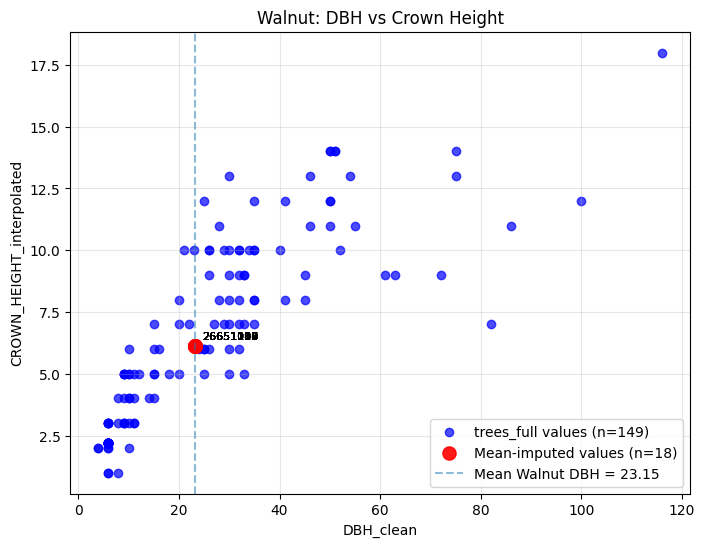

In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

species_name = "Walnut"

# -------------------------------
# 1. Original Walnut data from trees_full
# -------------------------------
full_species = trees_full[trees_full["COMMON_NAME"] == species_name].copy()

# original plottable Walnut points
full_species_plot = full_species[
    full_species["DBH_clean"].notna() &
    full_species["CROWN_HEIGHT_interpolated"].notna()
].copy()

print(f"{species_name} rows in trees_full (plottable): {len(full_species_plot)}")

# -------------------------------
# 2. Compute mean DBH for Walnut
# -------------------------------
walnut_mean_dbh = full_species["DBH_clean"].dropna().mean()
print(f"{species_name} mean DBH_clean: {walnut_mean_dbh:.2f}")

# -------------------------------
# 3. Find Walnut OBJECTIDs that were still missing in trees_full
#    after your DBH-based interpolation
# -------------------------------
remaining_missing_ids = set(
    full_species.loc[
        full_species["CROWN_HEIGHT_interpolated"].isna(),
        "OBJECTID"
    ]
)

print(f"{species_name} OBJECTIDs still missing in trees_full: {len(remaining_missing_ids)}")

# -------------------------------
# 4. Pull those same rows from trees_matched
#    (these should now contain the species-mean-filled crown heights)
# -------------------------------
matched_species = trees_matched[trees_matched["COMMON_NAME_radius"] == species_name].copy()

mean_imputed_species = matched_species[
    matched_species["OBJECTID"].isin(remaining_missing_ids) &
    matched_species["CROWN_HEIGHT_interpolated"].notna()
].copy()

print(f"{species_name} mean-imputed rows now in trees_matched: {len(mean_imputed_species)}")

# assign mean DBH for plotting on x-axis
mean_imputed_species["DBH_plot"] = walnut_mean_dbh

display(
    mean_imputed_species[
        ["OBJECTID", "COMMON_NAME_radius", "CROWN_HEIGHT_interpolated"]
    ].sort_values("CROWN_HEIGHT_interpolated")
)

# -------------------------------
# 5. Plot
# -------------------------------
plt.figure(figsize=(8, 6))

# blue = original / already available Walnut values from trees_full
plt.scatter(
    full_species_plot["DBH_clean"],
    full_species_plot["CROWN_HEIGHT_interpolated"],
    color="blue",
    alpha=0.7,
    label=f"trees_full values (n={len(full_species_plot)})"
)

# red = species-mean-filled values from trees_matched at mean Walnut DBH
if len(mean_imputed_species) > 0:
    plt.scatter(
        mean_imputed_species["DBH_plot"],
        mean_imputed_species["CROWN_HEIGHT_interpolated"],
        color="red",
        s=90,
        alpha=0.9,
        label=f"Mean-imputed values (n={len(mean_imputed_species)})"
    )

    # optional labels
    for _, row in mean_imputed_species.iterrows():
        plt.annotate(
            str(row["OBJECTID"]),
            (row["DBH_plot"], row["CROWN_HEIGHT_interpolated"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

# optional vertical line showing mean DBH location
plt.axvline(
    walnut_mean_dbh,
    linestyle="--",
    alpha=0.5,
    label=f"Mean Walnut DBH = {walnut_mean_dbh:.2f}"
)

plt.title(f"{species_name}: DBH vs Crown Height")
plt.xlabel("DBH_clean")
plt.ylabel("CROWN_HEIGHT_interpolated")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [83]:
trees_matched.to_csv(output_path, index=False)